# retro_game_classifier_1v2v3.ipynb

Colab notebook with **explicit** local data directories and **no destructive raw resets**.
Use this when you want to keep your Drive data safe and run all heavy processing on the local runtime first.


## 0. GPU & environment check


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


## 1. Mount Drive and define paths


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

# Local runtime paths
LOCAL_ROOT = Path('/content/retro-local-runtime')
REPO = LOCAL_ROOT / 'retro-game-classifier'
RAW_DIR = REPO / 'data' / 'raw'
PROCESSED_DIR = REPO / 'data' / 'processed'
FRAMES_DIR = PROCESSED_DIR / 'frames'
SPLITS_DIR = PROCESSED_DIR / 'splits'
AUDIODIR = PROCESSED_DIR / 'audio'
SPECSDIR = PROCESSED_DIR / 'spectrograms'
EXPORTS_DIR = REPO / 'exports'

# Ensure directory skeleton exists (no deletion)
for p in [
    RAW_DIR / 'SMB1', RAW_DIR / 'SMB2', RAW_DIR / 'SMB3',
    FRAMES_DIR, SPLITS_DIR, AUDIODIR, SPECSDIR, EXPORTS_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

print('LOCAL_ROOT =', LOCAL_ROOT)
print('REPO       =', REPO)
print('RAW_DIR    =', RAW_DIR)
print('FRAMES_DIR =', FRAMES_DIR)
print('SPLITS_DIR =', SPLITS_DIR)


Mounted at /content/drive
LOCAL_ROOT = /content/retro-local-runtime
REPO       = /content/retro-local-runtime/retro-game-classifier
RAW_DIR    = /content/retro-local-runtime/retro-game-classifier/data/raw
FRAMES_DIR = /content/retro-local-runtime/retro-game-classifier/data/processed/frames
SPLITS_DIR = /content/retro-local-runtime/retro-game-classifier/data/processed/splits


## 2. Clone or verify repo in local runtime


In [ ]:
from pathlib import Path
import shutil, os

LOCAL_ROOT = Path('/content/retro-local-runtime')
REPO = LOCAL_ROOT / 'retro-game-classifier'

LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

def ensure_clean_repo():
    # If REPO exists but is missing scripts/build_dataset.py, wipe it and reclone
    if REPO.exists():
        has_builder = (REPO / 'scripts' / 'build_dataset.py').exists()
        if not has_builder:
            print("Existing REPO is missing scripts/build_dataset.py; removing and recloning...")
            shutil.rmtree(REPO)
        else:
            print("Repo already exists and is valid at", REPO)
            return

    # Clone fresh if repo does not exist or was just removed
    if not REPO.exists():
        print("Cloning fresh repo into local runtime...")
        %cd /content
        !git clone https://github.com/rboro11/retro-game-classifier.git /content/retro-local-runtime/retro-game-classifier

    has_builder = (REPO / 'scripts' / 'build_dataset.py').exists()
    if not has_builder:
        raise RuntimeError(
            f"After clone, scripts/build_dataset.py is still missing in {REPO}.\n"
            "Check that this is really the retro-game-classifier repo."
        )
    os.chdir(REPO)
    print("Repo ready locally:", REPO)
    !find /content/retro-local-runtime/retro-game-classifier -maxdepth 2 | head -n 40

ensure_clean_repo()


Existing REPO is missing scripts/build_dataset.py; removing and recloning...
Cloning fresh repo into local runtime...
/content
Cloning into '/content/retro-local-runtime/retro-game-classifier'...
remote: Enumerating objects: 209, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 209 (delta 3), reused 0 (delta 0), pack-reused 200 (from 1)
Receiving objects: 100% (209/209), 15.64 MiB | 17.24 MiB/s, done.
Resolving deltas: 100% (92/92), done.
Repo ready locally: /content/retro-local-runtime/retro-game-classifier
/content/retro-local-runtime/retro-game-classifier
/content/retro-local-runtime/retro-game-classifier/README.md
/content/retro-local-runtime/retro-game-classifier/.git
/content/retro-local-runtime/retro-game-classifier/.git/description
/content/retro-local-runtime/retro-game-classifier/.git/objects
/content/retro-local-runtime/retro-game-classifier/.git/branches
/content/retro-local-runtime/retro-game-classifier/.git/pac

## 3. Configure your Drive source folders (EDIT paths once)


In [ ]:
from pathlib import Path

# TODO: update these to your actual Drive locations
SMB1_SRC = Path('/content/drive/MyDrive/SMB1 Pictures')
SMB2_SRC = Path('/content/drive/MyDrive/SMB2 Videos')
SMB3_SRC = Path('/content/drive/MyDrive/SMB3 videos')

print('SMB1_SRC exists:', SMB1_SRC.exists(), SMB1_SRC)
print('SMB2_SRC exists:', SMB2_SRC.exists(), SMB2_SRC)
print('SMB3_SRC exists:', SMB3_SRC.exists(), SMB3_SRC)


SMB1_SRC exists: True /content/drive/MyDrive/SMB1 Pictures
SMB2_SRC exists: True /content/drive/MyDrive/SMB2 Videos
SMB3_SRC exists: True /content/drive/MyDrive/SMB3 videos


## 4. Populate local raw folders from Drive (non-destructive)


In [ ]:
import shutil
from pathlib import Path

def copy_tree(src: Path, dst: Path):
    dst.mkdir(parents=True, exist_ok=True)
    count = 0
    for f in src.rglob('*'):
        if f.is_file():
            target = dst / f.name
            shutil.copy2(f, target)
            count += 1
    return count

counts = {}
if SMB1_SRC.exists(): counts['SMB1'] = copy_tree(SMB1_SRC, RAW_DIR / 'SMB1')
if SMB2_SRC.exists(): counts['SMB2'] = copy_tree(SMB2_SRC, RAW_DIR / 'SMB2')
if SMB3_SRC.exists(): counts['SMB3'] = copy_tree(SMB3_SRC, RAW_DIR / 'SMB3')

print('Copied counts:', counts)


Copied counts: {'SMB1': 1, 'SMB2': 1, 'SMB3': 7}


## 5. Preflight raw data check / Extract SMB1 database into processed frames


In [ ]:
import os
import re
import shutil
import subprocess
from pathlib import Path
from IPython.display import clear_output

archive_path = Path("/content/retro-local-runtime/retro-game-classifier/data/raw/SMB1/data-smb.7z")
extract_path = Path("/content/retro-local-runtime/retro-game-classifier/data/processed/frames/SMB1")

# Safety check
if extract_path.exists() and any(extract_path.iterdir()):
    print(f"⚠️ Warning: {extract_path} already contains extracted data.")
    confirm = input("Do you want to clear the existing folder and re-extract the archive? (yes/no): ").strip().lower()

    if confirm == "yes":
        print("Removing old extraction folder...")
        shutil.rmtree(extract_path)
        proceed = True
    else:
        print("Skipping extraction to preserve existing data.")
        proceed = False
else:
    proceed = True

if proceed:
    extract_path.mkdir(parents=True, exist_ok=True)

    if not archive_path.exists():
        print(f"❌ Error: Archive not found at {archive_path}")
    else:
        print(f"Starting extraction of {archive_path} ...")

        cmd = ["7z", "x", str(archive_path), f"-o{extract_path}", "-bsp1"]
        process = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1
        )

        percent_pattern = re.compile(r"(\d+)%")
        last_percent = None

        for line in process.stdout:
            match = percent_pattern.search(line)
            if match:
                pct = match.group(1)
                if pct != last_percent:
                    clear_output(wait=True)
                    print(f"Extracting SMB1 archive... {pct}%")
                    last_percent = pct

        process.wait()

        clear_output(wait=True)
        if process.returncode == 0:
            print("✅ Extraction complete: 100%")
            print(f"Extracted to: {extract_path}")
        else:
            print(f"❌ Extraction failed with exit code {process.returncode}")

✅ Extraction complete: 100%
Extracted to: /content/retro-local-runtime/retro-game-classifier/data/processed/frames/SMB1


In [ ]:
import shutil
from pathlib import Path

target_dir = Path('/content/retro-local-runtime/retro-game-classifier/data/processed/frames/SMB3')

if target_dir.exists():
    print(f"Cleaning directory: {target_dir}")
    # Remove the entire directory tree
    shutil.rmtree(target_dir)
    # Recreate the directory empty
    target_dir.mkdir(parents=True, exist_ok=True)
    print("All files deleted.")
else:
    print(f"Directory not found: {target_dir}")

Directory not found: /content/retro-local-runtime/retro-game-classifier/data/processed/frames/SMB3


## 6. Build processed frames locally


In [ ]:
%cd /content/retro-local-runtime/retro-game-classifier
!python scripts/build_dataset.py --mode frames --fps .3


/content

[extract_frames] FPS = 0.3  (images skipped — referenced directly from raw/)
  [GPU detected] Using -hwaccel auto for frame extraction.
  SMB1: no videos found, skipping.
  Extracting SMB2 Video_cropped.mp4 → SMB2/
  Extracting SMB3_2_cropped.mp4 → SMB3/
  Extracting SMB3_6_cropped.mp4 → SMB3/
  Extracting SMB3_1_cropped.mp4 → SMB3/
  Extracting SMB3_5_cropped.mp4 → SMB3/
  Extracting SMB3_3_cropped.mp4 → SMB3/
  Extracting SMB3_7_cropped.mp4 → SMB3/
  Extracting SMB3_4_cropped.mp4 → SMB3/
  Done. Total video-extracted frames: 742,162


## 7. Check local processed frame counts


In [ ]:
import glob

for cls in ['SMB1', 'SMB2', 'SMB3']:
    files = []
    for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp']:
        files += glob.glob(str(FRAMES_DIR / cls / '**' / ext), recursive=True)
    print(cls, 'processed frame count =', len(files))


SMB1 processed frame count = 737134
SMB2 processed frame count = 3888
SMB3 processed frame count = 1140


In [ ]:
from pathlib import Path
import shutil

REPO = Path('/content/retro-local-runtime/retro-game-classifier')
RAW_DIR = REPO / 'data' / 'raw'
PROCESSED_DIR = REPO / 'data' / 'processed'
FRAMES_DIR = PROCESSED_DIR / 'frames'

SMB1_RAW = RAW_DIR / 'SMB1'
SMB1_FRAMES = FRAMES_DIR / 'SMB1'

print("SMB1_RAW exists:", SMB1_RAW.exists(), SMB1_RAW)
print("SMB1_FRAMES exists:", SMB1_FRAMES.exists(), SMB1_FRAMES)

if not SMB1_RAW.exists():
    raise FileNotFoundError(f"SMB1_RAW not found at {SMB1_RAW}")

SMB1_FRAMES.mkdir(parents=True, exist_ok=True)

moved = 0
for f in SMB1_RAW.rglob('*'):
    if f.is_file() and f.suffix.lower() in ['.png', '.jpg', '.jpeg', '.bmp']:
        dst = SMB1_FRAMES / f.name  # flatten names; adjust if you want subfolders
        shutil.move(str(f), str(dst))
        moved += 1

print(f"Moved {moved} SMB1 image files from RAW to PROCESSED/frames")

# Optional: clean up any now-empty subdirectories under SMB1_RAW
for p in sorted(SMB1_RAW.rglob('*'), reverse=True):
    if p.is_dir():
        try:
            p.rmdir()
        except OSError:
            pass

SMB1_RAW exists: True /content/retro-local-runtime/retro-game-classifier/data/raw/SMB1
SMB1_FRAMES exists: True /content/retro-local-runtime/retro-game-classifier/data/processed/frames/SMB1
Moved 0 SMB1 image files from RAW to PROCESSED/frames


## 8. Build train/val/test splits locally


In [ ]:
%cd /content/retro-local-runtime/retro-game-classifier
!python scripts/build_dataset.py --mode splits --max_per_class 1000


/content
  [session-split] SMB1: 737,134 frames across 280 sessions → capped to ~1,000  (train=702 val=149 test=148)
    Test sessions  (42): ['Rafael_ra0d7ivk_e29_5-2_win', 'Rafael_cyj0sfke_e15_8-3_fail', 'Rafael_ra0d7ivk_e30_5-3_fail', 'Rafael_ra0d7ivk_e77_8-2_win', 'Rafael_ra0d7ivk_e68_8-2_fail']...
    Val  sessions  (42):  ['Rafael_cyj0sfke_e54_8-4_fail', 'Rafael_ra0d7ivk_e4_1-3_win', 'Rafael_dp2a9j4i_e42_8-3_fail', 'Rafael_cyj0sfke_e43_8-2_win', 'Rafael_ra0d7ivk_e47_7-1_win']...
    Train sessions (196): ['Rafael_psfmjpx6_e23_5-1_win', 'Rafael_psfmjpx6_e6_2-3_win', 'Rafael_gb32o9qm_e21_8-4_fail', 'Rafael_ra0d7ivk_e67_8-1_win', 'Rafael_cyj0sfke_e20_8-1_fail']...
  WARNING [SMB2]: only 1 video clip(s) detected — not enough to fill train/val/test at the clip level.
  Falling back to CHRONOLOGICAL FRAME-LEVEL split (sorted by filename, sliced sequentially).
  test=15% of early frames | val=15% of middle frames | train=remainder of later frames.
  [frame-level-fallback] SMB2: 3,888 fr

## 9. Verify local classes and split balance


In [ ]:
import pandas as pd

classes_df = pd.read_csv(SPLITS_DIR / 'classes.csv')
print(classes_df)

for split in ['train', 'val', 'test']:
    df = pd.read_csv(SPLITS_DIR / f'{split}.csv')
    print(f"\n{split.upper()} rows =", len(df))
    print(df['label'].value_counts())

  label  label_idx
0  SMB1          0
1  SMB2          1
2  SMB3          2

TRAIN rows = 2132
label
SMB3    730
SMB1    702
SMB2    700
Name: count, dtype: int64

VAL rows = 455
label
SMB3    157
SMB1    149
SMB2    149
Name: count, dtype: int64

TEST rows = 408
label
SMB2    149
SMB1    148
SMB3    111
Name: count, dtype: int64


## 10. Train EfficientNet-B0 3-class model locally


In [ ]:
%cd /content/retro-local-runtime/retro-game-classifier
!python scripts/train_model.py --model efficientnet_b0 --num_classes 3 --epochs 20 --batch_size 32 --lr 3e-4


/content
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100% 20.5M/20.5M [00:00<00:00, 160MB/s]

Model: EfficientNet-B0 | img_size=224 | classes=3
Train: 2,132 samples | Val: 455 samples
Classes: ['SMB1', 'SMB2', 'SMB3']
/content/retro-local-runtime/retro-game-classifier/src/training/trainer.py:89: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler(enabled=config.amp)

  Model:  EfficientNet-B0
  Device: cuda  |  AMP: True
  Classes: 3  |  Epochs: 20

Train:   0% 0/67 [00:00<?, ?it/s]/content/retro-local-runtime/retro-game-classifier/src/training/trainer.py:119: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.cfg.amp):
Epoch [  1/20]  Train: loss=0.3974 acc=0.9568 

## 11. Evaluate locally


In [ ]:
%cd /content/retro-local-runtime/retro-game-classifier
!python scripts/evaluate.py


/content
Device: cuda

  Checkpoint: EfficientNet-B0_best.pt
  Model: EfficientNet-B0  |  img_size: 224
  Test samples: 408  |  Classes: ['SMB1', 'SMB2', 'SMB3']

  Test Accuracy : 1.0000
  Macro F1      : 1.0000
  Macro Precision: 1.0000
  Macro Recall   : 1.0000

  Per-class report:
              precision    recall  f1-score   support

        SMB1       1.00      1.00      1.00       148
        SMB2       1.00      1.00      1.00       149
        SMB3       1.00      1.00      1.00       111

    accuracy                           1.00       408
   macro avg       1.00      1.00      1.00       408
weighted avg       1.00      1.00      1.00       408

  Confusion matrix → /content/retro-local-runtime/retro-game-classifier/reports/eval_EfficientNet-B0_confusion.png

  FINAL SUMMARY
          model  test_acc  macro_f1  precision  recall  n_test
EfficientNet-B0       1.0       1.0        1.0     1.0     408

Summary saved → /content/retro-local-runtime/retro-game-classifier/reports

## 12. Export bundle locally


In [ ]:
%cd /content/retro-local-runtime/retro-game-classifier
!python scripts/export_model.py


/content
Best model by test accuracy: EfficientNet-B0 (1.0000)

Loading checkpoint: EfficientNet-B0_best.pt

✓ Exported → /content/retro-local-runtime/retro-game-classifier/exports/EfficientNet-B0_export.pt  (16.3 MB)
✓ Metadata sidecar → /content/retro-local-runtime/retro-game-classifier/exports/EfficientNet-B0_export.json

Bundle contents:
  architecture : {'registry_key': 'efficientnet_b0', 'display_name': 'EfficientNet-B0', 'num_classes': 3}
  class_names  : ['SMB1', 'SMB2', 'SMB3']
  img_size     : 224
  val_acc      : 0.9956043956043956
  test_acc     : 1.0
  size         : 16.3 MB


# 13. Benchmark and display evaluation

/content
From https://github.com/rboro11/retro-game-classifier
 * branch            main       -> FETCH_HEAD
Already up to date.
Classes: ['SMB1', 'SMB2', 'SMB3']
Loaded history: EfficientNet-B0 (best_val_acc=0.9956)
EfficientNet-B0: test accuracy = 1.0000

Checkpoints loaded: 1  |  skipped: 0

✓ Benchmark report saved → /content/retro-local-runtime/retro-game-classifier/reports/benchmark_report.png

────────────────────────────────────────────────────────────
          Model  Best Val Acc  Best Epoch  Train Time (min)  Test Acc  Macro F1
EfficientNet-B0        0.9956           1              4.71       1.0       1.0
────────────────────────────────────────────────────────────
Saved → /content/retro-local-runtime/retro-game-classifier/reports/val_acc_comparison.png

All reports saved to /content/retro-local-runtime/retro-game-classifier/reports/


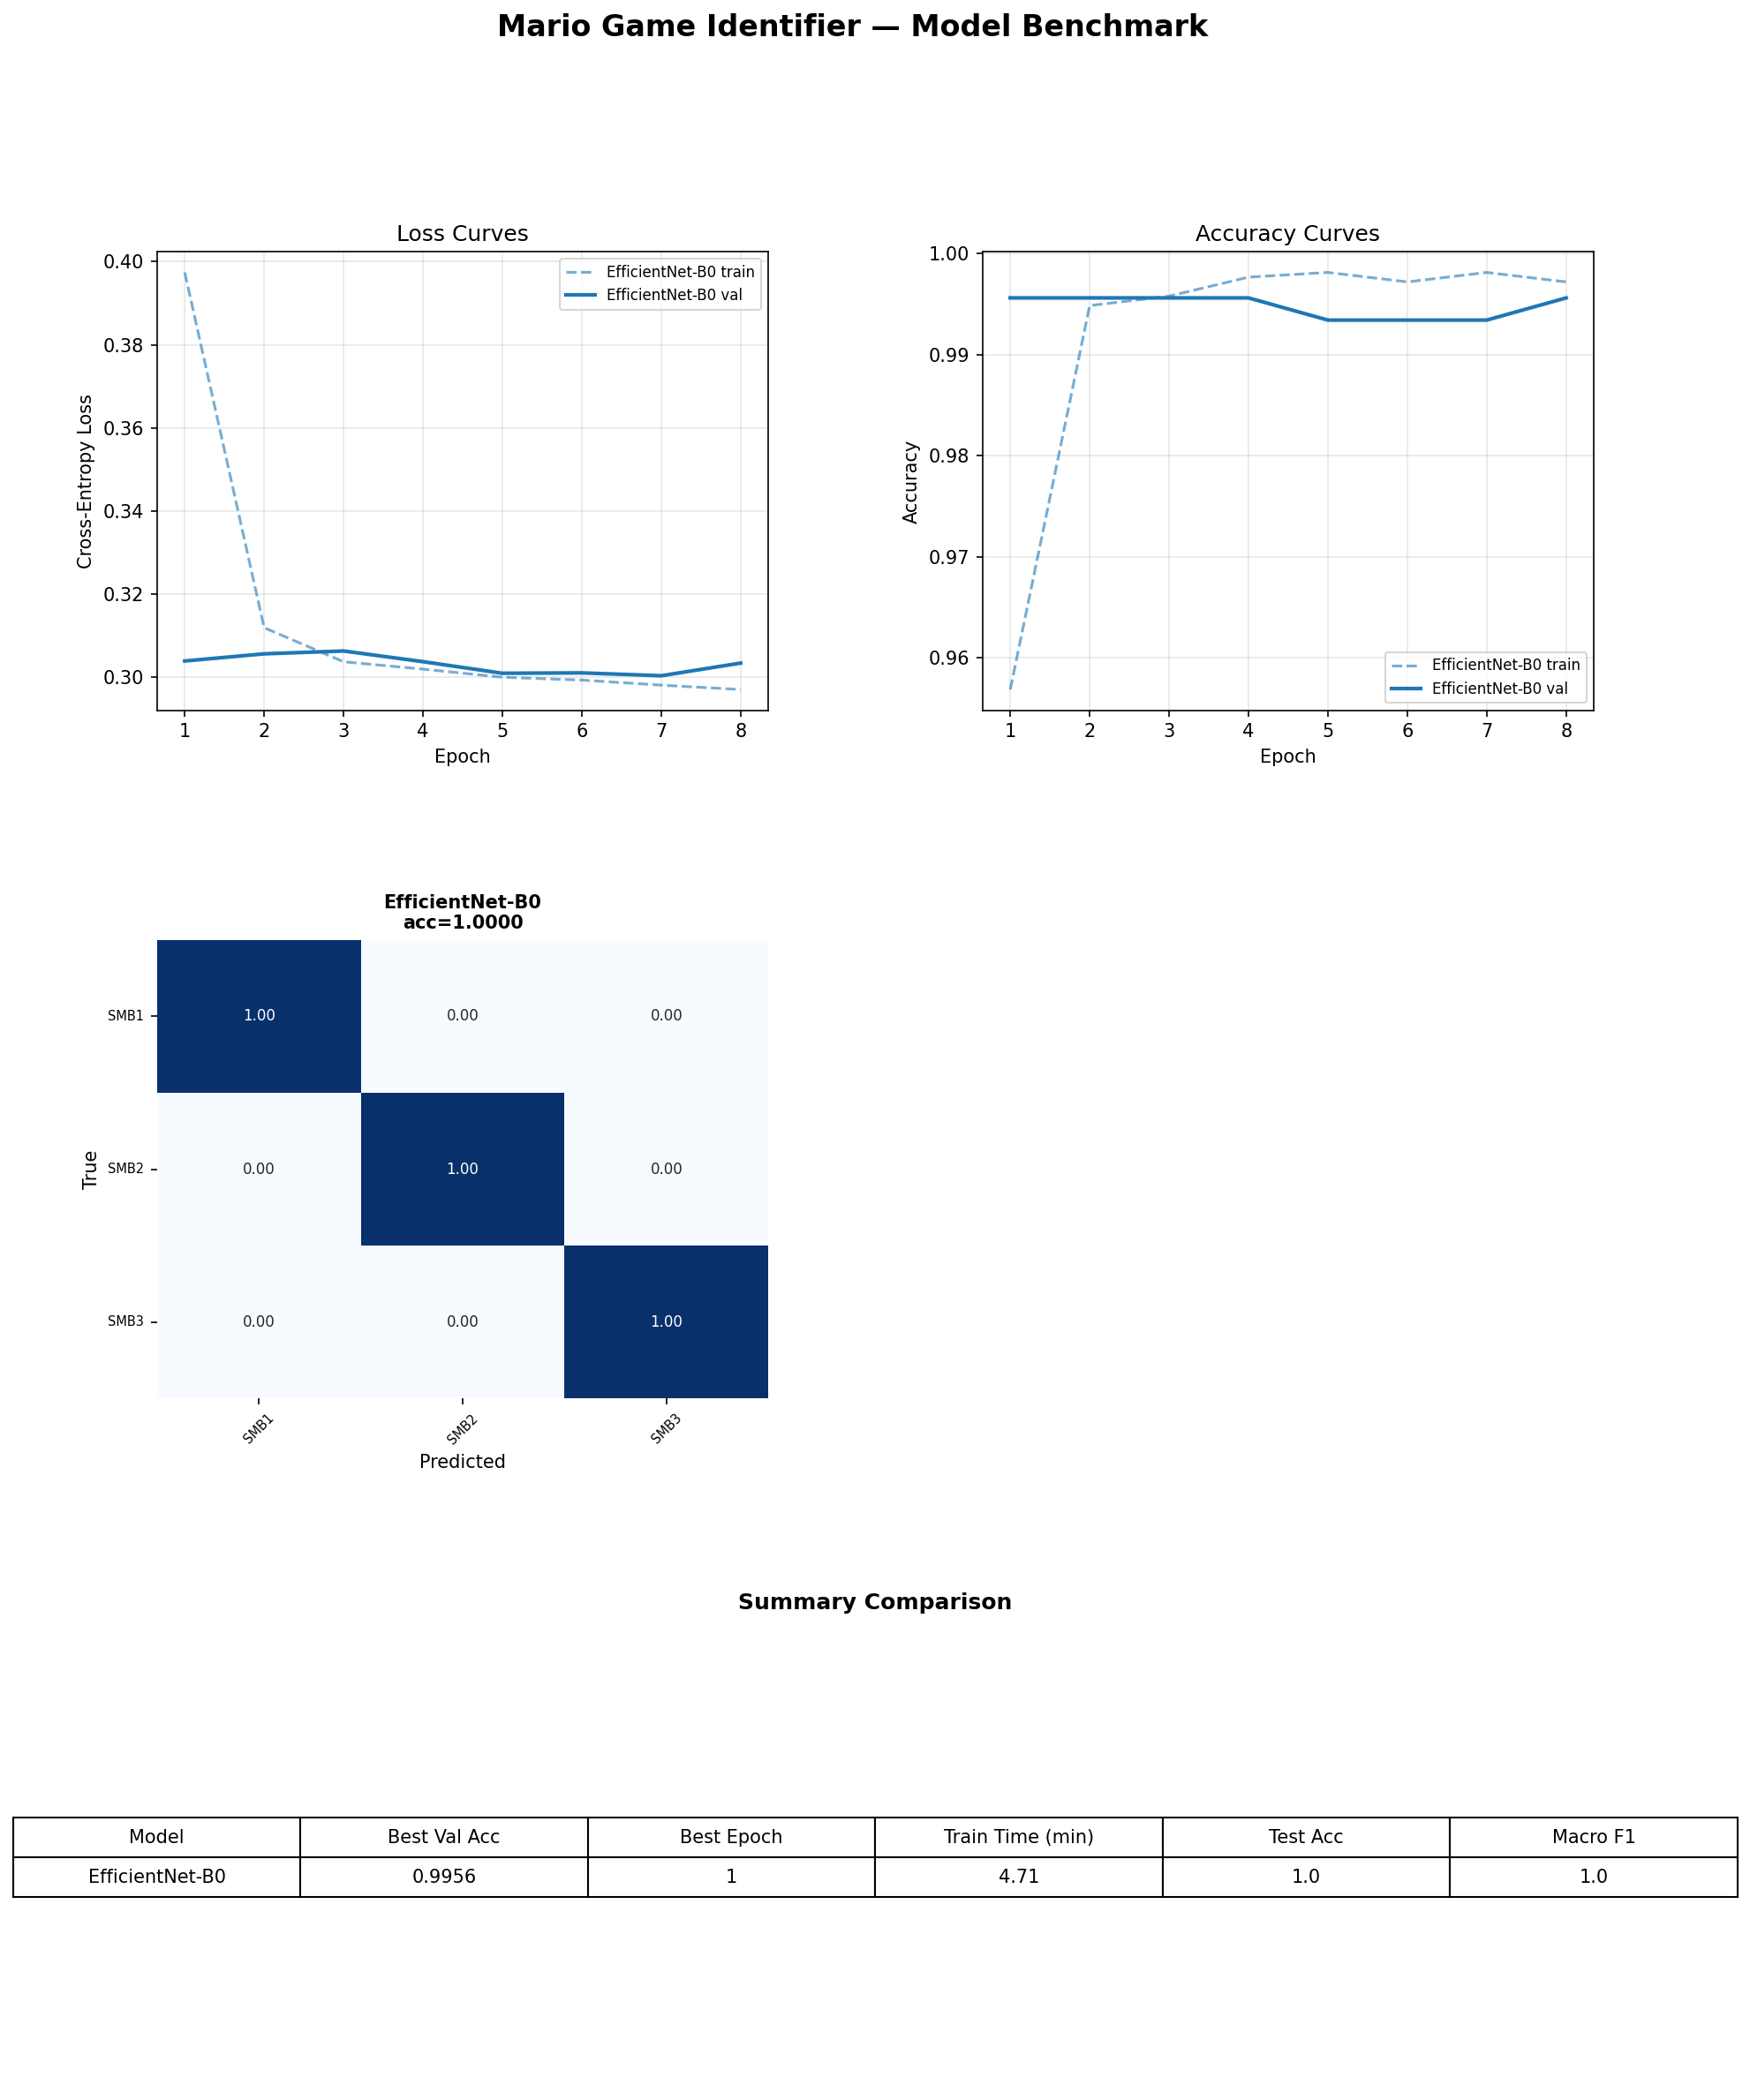

In [ ]:
# Display benchmark report inline ───────────────────────
%cd /content/retro-local-runtime/retro-game-classifier
!git pull origin main
!python scripts/run_benchmark.py


import os
from IPython.display import Image, display
report_path = 'reports/benchmark_report.png'
if os.path.exists(report_path):
  display(Image(report_path))
else:
  print(f"❌ Error: '{report_path}' not found.")
  print("This is likely because the benchmark script (Cell pxE9QwdcbJos) crashed with a TypeError.")
  print("The crash happens because the benchmarker encountered an 'unknown model' and couldn't sort the results table.")

## 14. Check local export bundle


In [ ]:
import torch

bundle_path = EXPORTS_DIR / 'EfficientNet-B0_export.pt'
assert bundle_path.exists(), f'Missing export: {bundle_path}'

bundle = torch.load(bundle_path, map_location='cpu')
print('Export exists:', bundle_path)
print('num_classes:', bundle.get('num_classes'))
print('class_names:', bundle.get('class_names'))


Export exists: /content/retro-local-runtime/retro-game-classifier/exports/EfficientNet-B0_export.pt
num_classes: None
class_names: None


## 14. Copy files back to Drive


In [ ]:
# Save all relevant outputs back to Drive

from pathlib import Path
import shutil

project = Path("/content/retro-local-runtime/retro-game-classifier")
drive_root = Path("/content/drive/MyDrive/retro-game-classifier")

pairs = {
    "Checkpoints": (project / "checkpoints", drive_root / "checkpoints"),
    "Reports": (project / "reports", drive_root / "reports"),
    "Splits": (project / "data/processed/splits", drive_root / "splits"),
}

for name, (src, dst) in pairs.items():
    if src.exists():
        dst.mkdir(parents=True, exist_ok=True)
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"✅ {name}: copied {src} -> {dst}")
    else:
        print(f"⚠️ {name}: source {src} not found, skipping.")

print("📦 Drive backup complete.")


✅ Checkpoints: copied /content/retro-local-runtime/retro-game-classifier/checkpoints -> /content/drive/MyDrive/retro-game-classifier/checkpoints
✅ Reports: copied /content/retro-local-runtime/retro-game-classifier/reports -> /content/drive/MyDrive/retro-game-classifier/reports
✅ Splits: copied /content/retro-local-runtime/retro-game-classifier/data/processed/splits -> /content/drive/MyDrive/retro-game-classifier/splits
📦 Drive backup complete.


In [ ]:
from pathlib import Path
import torch
import pandas as pd

REPO = Path('/content/retro-local-runtime/retro-game-classifier')
EXPORTS_DIR = REPO / 'exports'
SPLITS_DIR = REPO / 'data' / 'processed' / 'splits'

bundle_path = EXPORTS_DIR / 'EfficientNet-B0_export.pt'
assert bundle_path.exists(), f"Missing export {bundle_path}"

bundle = torch.load(bundle_path, map_location='cpu')
print("Export exists:", bundle_path)

num_classes_bundle = bundle.get('num_classes', None)
class_names_bundle = bundle.get('class_names', None)

print("num_classes (bundle):", num_classes_bundle)
print("class_names (bundle):", class_names_bundle)

# Fallback to splits if bundle metadata is missing or None
if num_classes_bundle is None or class_names_bundle is None:
    classes_df = pd.read_csv(SPLITS_DIR / 'classes.csv')
    print("\nUsing classes.csv as source of truth:")
    print(classes_df)

    num_classes = len(classes_df)
    class_names = classes_df['label'].tolist()

    print("num_classes (splits):", num_classes)
    print("class_names (splits):", class_names)
else:
    num_classes = num_classes_bundle
    class_names = class_names_bundle

print("\nFinal class metadata that will be assumed for deployment:")
print("num_classes:", num_classes)
print("class_names:", class_names)

Export exists: /content/retro-local-runtime/retro-game-classifier/exports/EfficientNet-B0_export.pt
num_classes (bundle): None
class_names (bundle): None

Using classes.csv as source of truth:
  label  label_idx
0  SMB1          0
1  SMB2          1
2  SMB3          2
num_classes (splits): 3
class_names (splits): ['SMB1', 'SMB2', 'SMB3']

Final class metadata that will be assumed for deployment:
num_classes: 3
class_names: ['SMB1', 'SMB2', 'SMB3']


In [ ]:
# Install Hugging Face hub if needed
!pip install -q huggingface_hub

from huggingface_hub import HfApi, login
from pathlib import Path

# 1. Configure your token
HUGGINGFACE_TOKEN = ""
# Use login instead of HfFolder
login(token=HUGGINGFACE_TOKEN)

# 2. Set repo info
HF_REPO_ID = "rboro11/retro-game-classifier"

REPO = Path('/content/retro-local-runtime/retro-game-classifier')
EXPORTS_DIR = REPO / 'exports'
bundle_path = EXPORTS_DIR / 'EfficientNet-B0_export.pt'

assert bundle_path.exists(), f"Missing export {bundle_path}"

api = HfApi()

# 3. Upload the export file
api.upload_file(
    path_or_fileobj=str(bundle_path),
    path_in_repo="EfficientNet-B0_export.pt",
    repo_id=HF_REPO_ID,
    repo_type="space",
    token=HUGGINGFACE_TOKEN,
)

print(f"Uploaded {bundle_path} to Hugging Face repo {HF_REPO_ID} as EfficientNet-B0_export.pt")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...EfficientNet-B0_export.pt:   0%|          | 22.4kB / 16.3MB            

Uploaded /content/retro-local-runtime/retro-game-classifier/exports/EfficientNet-B0_export.pt to Hugging Face repo rboro11/retro-game-classifier as EfficientNet-B0_export.pt


In [ ]:
from pathlib import Path
from huggingface_hub import HfApi

api = HfApi()

REPO = Path('/content/retro-local-runtime/retro-game-classifier')
classes_path = REPO / 'data' / 'processed' / 'splits' / 'classes.csv'

api.upload_file(
    path_or_fileobj=str(classes_path),
    path_in_repo="classes.csv",
    repo_id="rboro11/retro-game-classifier",
    repo_type="space",
    token=HUGGINGFACE_TOKEN,
)

print("Uploaded classes.csv")

No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded classes.csv


In [ ]:
HUGGINGFACE_TOKEN = ""

from pathlib import Path
from huggingface_hub import HfApi

app_text = """import sys
from pathlib import Path

import gradio as gr
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image, ImageOps
from torchvision import transforms

ROOT = Path(__file__).resolve().parent
sys.path.insert(0, str(ROOT / "src"))

BUNDLE_PATH = ROOT / "exports" / "EfficientNet-B0_export.pt"
CLASSES_PATH = ROOT / "classes.csv"

if not BUNDLE_PATH.exists():
    raise FileNotFoundError(f"Export bundle not found at {BUNDLE_PATH}. Run: python scripts/export_model.py")

bundle = torch.load(BUNDLE_PATH, map_location="cpu", weights_only=False)

arch = bundle["architecture"]
inf_cfg = bundle.get("inference", {})
training = bundle.get("training", {})

CLASS_NAMES = inf_cfg.get("class_names")
if not CLASS_NAMES:
    if CLASSES_PATH.exists():
        classes_df = pd.read_csv(CLASSES_PATH)
        CLASS_NAMES = classes_df["label"].tolist()
    else:
        raise ValueError("No class_names found in export bundle and classes.csv is missing.")

IMG_SIZE = inf_cfg.get("img_size", 224)
MEAN = inf_cfg.get("mean", [0.485, 0.456, 0.406])
STD = inf_cfg.get("std", [0.229, 0.224, 0.225])

from models.transfer_models import build_model
from models.cnn_custom import MarioCNNSmall, MarioCNNMedium

key = arch["registry_key"]
n = arch["num_classes"]

if key == "cnn_small":
    model = MarioCNNSmall(num_classes=n)
elif key == "cnn_medium":
    model = MarioCNNMedium(num_classes=n)
else:
    model, _ = build_model(key, num_classes=n)

model.load_state_dict(bundle["model_state"])
model.eval()

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

def prepare_image(image: Image.Image) -> Image.Image:
    image = ImageOps.exif_transpose(image)
    image = image.convert("RGB")
    w, h = image.size
    crop_size = min(w, h)
    left = (w - crop_size) // 2
    top = (h - crop_size) // 2
    right = left + crop_size
    bottom = top + crop_size
    image = image.crop((left, top, right, bottom))
    return image

def classify(image: Image.Image) -> dict:
    if image is None:
        return {c: 0.0 for c in CLASS_NAMES}

    image = prepare_image(image)
    tensor = preprocess(image).unsqueeze(0)

    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1).squeeze(0)

    return {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}

examples_dir = ROOT / "examples"
EXAMPLES = [str(p) for p in sorted(examples_dir.glob("*.png"))] if examples_dir.exists() else []

best_val_acc = training.get("best_val_acc")
test_acc = training.get("test_acc")

model_info_parts = [f"**Model:** {arch.get('display_name', 'EfficientNet-B0')}"]
if best_val_acc is not None:
    model_info_parts.append(f"**Val acc:** {best_val_acc:.2%}")
if test_acc is not None:
    model_info_parts.append(f"**Test acc:** {test_acc:.2%}")
model_info_parts.append(f"**Classes:** {', '.join(CLASS_NAMES)}")
MODEL_INFO = " | ".join(model_info_parts)

DESCRIPTION = "Upload a screenshot or gameplay frame and the model will identify whether the image is from Super Mario Bros., Super Mario Bros. 2, or Super Mario Bros. 3."
TIP_TEXT = "This version uses a 3-class retro game classifier trained on self-collected gameplay imagery. Direct screenshots usually give the best results. If using the camera, point it straight at the screen and crop out borders for highest accuracy."
FOOTER = "Source: https://github.com/rboro11/retro-game-classifier | EfficientNet-B0 retro game classifier for SMB1, SMB2, and SMB3."

with gr.Blocks(title="Retro Game Classifier", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# Retro Game Classifier")
    gr.Markdown(DESCRIPTION)
    gr.Markdown(TIP_TEXT)
    gr.Markdown(MODEL_INFO)

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                type="pil",
                label="Upload a gameplay screenshot",
                sources=["upload", "webcam", "clipboard"],
                height=300,
            )
            submit_btn = gr.Button("Classify", variant="primary")

        with gr.Column(scale=1):
            label_output = gr.Label(
                label="Prediction",
                num_top_classes=len(CLASS_NAMES),
            )

    if EXAMPLES:
        gr.Examples(
            examples=EXAMPLES,
            inputs=image_input,
            outputs=label_output,
            fn=classify,
            cache_examples=True,
        )

    submit_btn.click(fn=classify, inputs=image_input, outputs=label_output)
    image_input.change(fn=classify, inputs=image_input, outputs=label_output)

    gr.Markdown(FOOTER)

if __name__ == "__main__":
    demo.launch(share=False)
"""

Path("/content/app.py").write_text(app_text, encoding="utf-8")
print("Wrote /content/app.py")

api = HfApi()
api.upload_file(
    path_or_fileobj="/content/app.py",
    path_in_repo="app.py",
    repo_id="rboro11/retro-game-classifier",
    repo_type="space",
    token=HUGGINGFACE_TOKEN,
)

print("Uploaded clean app.py to the Space")

No files have been modified since last commit. Skipping to prevent empty commit.


Wrote /content/app.py
Uploaded clean app.py to the Space
